In [25]:
import yfinance as yf
import truststore
truststore.inject_into_ssl()

t = "ZNU26.CBT"  # Mar-2025 contract exists on Yahoo :contentReference[oaicite:1]{index=1}
df = yf.download(t, start="2024-01-01", end="2026-12-31", progress=False)
print(df.head())

Price            Close        High         Low        Open    Volume
Ticker       ZNU26.CBT   ZNU26.CBT   ZNU26.CBT   ZNU26.CBT ZNU26.CBT
Date                                                                
2025-12-19  112.281250  112.281250  112.281250  112.281250         0
2025-12-22  112.125000  112.125000  112.125000  112.125000         0
2025-12-23  112.093750  112.093750  112.093750  112.093750         0
2025-12-24  112.296875  112.296875  112.296875  112.296875         0
2025-12-26  112.359375  112.359375  112.359375  112.359375         0


In [ ]:
import yfinance as yf

# fixed CME/CBOT contracts on Yahoo
symbols = ["ZNU26.CBT", "ZNM26.CBT", "ZNZ24.CBT"]

for s in symbols:
    df = yf.download(s, auto_adjust=False, actions=False)
    df.to_csv(f"{s}.csv")
    print(s, df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


ZNU26.CBT Price        Adj Close       Close        High        Low        Open  \
Ticker       ZNU26.CBT   ZNU26.CBT   ZNU26.CBT  ZNU26.CBT   ZNU26.CBT   
Date                                                                    
2026-03-02  112.937500  112.937500  113.937500  112.75000  113.937500   
2026-03-03  112.875000  112.875000  112.968750  112.50000  112.968750   
2026-03-04  112.671875  112.671875  112.828125  112.59375  112.734375   
2026-03-05  112.171875  112.171875  112.609375  112.12500  112.609375   
2026-03-06  112.296875  112.296875  112.546875  111.90625  112.250000   

Price         Volume  
Ticker     ZNU26.CBT  
Date                  
2026-03-02       139  
2026-03-03       135  
2026-03-04        58  
2026-03-05       103  
2026-03-06       109  
ZNM26.CBT Price        Adj Close       Close        High         Low        Open  \
Ticker       ZNM26.CBT   ZNM26.CBT   ZNM26.CBT   ZNM26.CBT   ZNM26.CBT   
Date                                                           

$ZNZ24.CBT: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ZNZ24.CBT']: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")


ZNZ24.CBT Empty DataFrame
Columns: [(Adj Close, ZNZ24.CBT), (Close, ZNZ24.CBT), (High, ZNZ24.CBT), (Low, ZNZ24.CBT), (Open, ZNZ24.CBT), (Volume, ZNZ24.CBT)]
Index: []


: 

In [27]:
import datetime as dt
import time
import pandas as pd
import requests
from typing import Optional

# If you're on Windows/corporate network, this often helps:
# pip install truststore
import truststore
truststore.inject_into_ssl()

def yahoo_chart_ohlcv(
    symbol: str,
    start: str,
    end: str,
    interval: str = "1d",
    session: Optional[requests.Session] = None,
) -> pd.DataFrame:
    """
    Download OHLCV from Yahoo chart endpoint (no yfinance).
    Returns a DataFrame indexed by UTC timestamp (you can .tz_convert() or take .date).
    """
    s = pd.Timestamp(start, tz="UTC")
    e = pd.Timestamp(end, tz="UTC")

    url = f"https://query1.finance.yahoo.com/v8/finance/chart/{symbol}"
    params = {
        "period1": int(s.timestamp()),
        "period2": int(e.timestamp()),
        "interval": interval,
        "events": "history",
        "includeAdjustedClose": "true",
    }
    headers = {
        "User-Agent": "Mozilla/5.0",  # helps reduce 429s
        "Accept": "application/json,text/plain,*/*",
    }

    sess = session or requests.Session()
    r = sess.get(url, params=params, headers=headers, timeout=30)

    # If you get 429, back off and retry manually or add sleep between calls
    r.raise_for_status()
    j = r.json()

    err = j.get("chart", {}).get("error")
    if err:
        raise RuntimeError(f"Yahoo chart error: {err}")

    res = j["chart"]["result"][0]
    ts = pd.to_datetime(res["timestamp"], unit="s", utc=True)

    quote = res["indicators"]["quote"][0]
    df = pd.DataFrame(
        {
            "open": quote.get("open"),
            "high": quote.get("high"),
            "low": quote.get("low"),
            "close": quote.get("close"),
            "volume": quote.get("volume"),
        },
        index=ts,
    )

    # Sometimes adjclose exists
    adj = res["indicators"].get("adjclose")
    if adj and len(adj) > 0:
        df["adjclose"] = adj[0].get("adjclose")

    # Drop rows with no close (weekends/holes)
    df = df.dropna(subset=["close"]).sort_index()
    return df

# Example: pull 2015-2025 daily bars
df = yahoo_chart_ohlcv("ZN=F", "2015-01-01", "2026-01-01", "1d")
df.to_csv("ZN_equalF_yahoo_chart.csv")
print(df.head())
print(df.tail())

                                 open        high         low       close  \
2015-01-02 05:00:00+00:00  126.609375  127.328125  126.406250  127.156250   
2015-01-05 05:00:00+00:00  127.156250  127.843750  127.046875  127.765625   
2015-01-06 05:00:00+00:00  127.750000  129.109375  127.734375  128.359375   
2015-01-07 05:00:00+00:00  128.500000  128.687500  128.015625  128.468750   
2015-01-08 05:00:00+00:00  128.312500  128.375000  127.968750  128.109375   

                              volume    adjclose  
2015-01-02 05:00:00+00:00   768078.0  127.156250  
2015-01-05 05:00:00+00:00   901819.0  127.765625  
2015-01-06 05:00:00+00:00  1739806.0  128.359375  
2015-01-07 05:00:00+00:00  1481757.0  128.468750  
2015-01-08 05:00:00+00:00   941743.0  128.109375  
                                 open        high         low       close  \
2025-12-24 14:30:00+00:00  112.296875  112.531250  112.265625  112.515625   
2025-12-26 05:00:00+00:00  112.515625  112.718750  112.375000  112.578125   


In [28]:
import numpy as np
import pandas as pd

# --- assume df from the yahoo_chart_ohlcv function, indexed by timestamps, with 'close' ---
# df = yahoo_chart_ohlcv(...)

# Use close-to-close returns
df = df.copy()
df["ret"] = df["close"].pct_change()

# Example signal: 20d momentum (long if price up over last 20 days)
lookback = 20
df["signal"] = np.sign(df["close"].pct_change(lookback)).replace(0, np.nan).ffill().fillna(0)

# Position is yesterday's signal (trade at close, hold next day) to avoid lookahead
df["pos"] = df["signal"].shift(1).fillna(0)

# Futures $ P&L approximation:
# CME convention: 1 point move ~= $1000 per contract for ZN (10Y note future) :contentReference[oaicite:8]{index=8}
POINT_VALUE = 1000.0
df["dprice"] = df["close"].diff()
df["pnl_gross_$"] = df["pos"] * df["dprice"] * POINT_VALUE

# Transaction costs: assume 1 tick per change in position (very rough)
# Tick size is 1/2 of 1/32 = 1/64 of a point; tick value $15.625 :contentReference[oaicite:9]{index=9}
TICK_VALUE = 15.625
df["turnover"] = df["pos"].diff().abs()
df["cost_$"] = df["turnover"] * TICK_VALUE

df["pnl_net_$"] = df["pnl_gross_$"] - df["cost_$"]
df["equity_$"] = df["pnl_net_$"].cumsum()

# Quick metrics
daily_pnl = df["pnl_net_$"].dropna()
sharpe = (daily_pnl.mean() / daily_pnl.std()) * np.sqrt(252) if daily_pnl.std() > 0 else np.nan
max_dd = (df["equity_$"] - df["equity_$"].cummax()).min()

print("Sharpe (net):", sharpe)
print("Max drawdown ($):", max_dd)
print(df[["close","pos","pnl_net_$","equity_$"]].tail(5))

Sharpe (net): -0.4825688014372587
Max drawdown ($): -35187.5
                                close  pos  pnl_net_$   equity_$
2025-12-24 14:30:00+00:00  112.515625 -1.0   -218.750 -34984.375
2025-12-26 05:00:00+00:00  112.578125 -1.0    -62.500 -35046.875
2025-12-29 05:00:00+00:00  112.718750 -1.0   -140.625 -35187.500
2025-12-30 05:00:00+00:00  112.640625 -1.0     78.125 -35109.375
2025-12-31 05:00:00+00:00  112.437500 -1.0    203.125 -34906.250


In [29]:
# Large one-day jumps can indicate a roll discontinuity or bad print
df["jump_bp"] = (df["close"] / df["close"].shift(1) - 1) * 1e4  # in "bp of price", just for scale
print(df["jump_bp"].abs().sort_values(ascending=False).head(10))

2023-03-23 04:00:00+00:00    199.230558
2022-11-10 05:00:00+00:00    198.272199
2022-09-28 04:00:00+00:00    177.539806
2020-03-16 04:00:00+00:00    166.839259
2023-03-10 05:00:00+00:00    144.968332
2020-03-17 04:00:00+00:00    144.861928
2023-11-14 05:00:00+00:00    136.707388
2023-03-13 04:00:00+00:00    134.572697
2024-04-10 04:00:00+00:00    131.110161
2023-03-17 04:00:00+00:00    129.227385
Name: jump_bp, dtype: float64


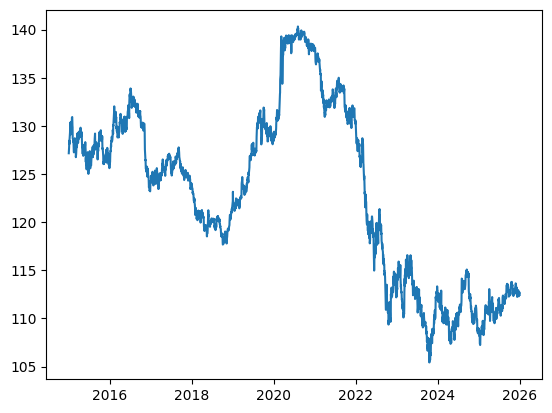

In [31]:
import matplotlib.pyplot as plt
plt.plot(df[["close"]])

In [11]:
import yfinance as yf

tests = [
    ("ZN=F", "2015-01-01", "2025-12-31"),      # continuous (Yahoo’s generic)
    ("ZNM26.CBT", "2025-01-01", "2026-12-31"), # a current-ish contract example
    ("ZNH25.CBT", "2024-01-01", "2025-04-01"), # your target
]

for t, start, end in tests:
    print("\n=== ", t, " ===")
    df = yf.download(t, start=start, end=end, progress=False, auto_adjust=False)
    print("rows:", len(df))
    if len(df):
        print(df.tail(3))


===  ZN=F  ===
rows: 2765
Price        Adj Close       Close        High         Low        Open  \
Ticker            ZN=F        ZN=F        ZN=F        ZN=F        ZN=F   
Date                                                                     
2025-12-26  112.578125  112.578125  112.718750  112.375000  112.515625   
2025-12-29  112.718750  112.718750  112.781250  112.484375  112.578125   
2025-12-30  112.640625  112.640625  112.796875  112.531250  112.734375   

Price        Volume  
Ticker         ZN=F  
Date                 
2025-12-26   774752  
2025-12-29  1188578  
2025-12-30  1058870  

===  ZNM26.CBT  ===


$ZNH25.CBT: possibly delisted; no timezone found

1 Failed download:
['ZNH25.CBT']: possibly delisted; no timezone found


rows: 133
Price        Adj Close       Close       High         Low        Open  \
Ticker       ZNM26.CBT   ZNM26.CBT  ZNM26.CBT   ZNM26.CBT   ZNM26.CBT   
Date                                                                    
2026-03-27  110.156250  110.156250  110.31250  109.750000  110.203125   
2026-03-30  110.812500  110.812500  110.96875  110.125000  110.171875   
2026-03-31  110.984375  110.984375  111.06250  110.703125  110.765625   

Price         Volume  
Ticker     ZNM26.CBT  
Date                  
2026-03-27   2608633  
2026-03-30   2608633  
2026-03-31    346934  

===  ZNH25.CBT  ===
rows: 0


In [12]:
url = "https://query2.finance.yahoo.com/v8/finance/chart/ZNH25.CBT?range=5d&interval=1d"
r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
print("status:", r.status_code)
print("first 300 chars:", r.text[:300])

status: 404
first 300 chars: {"chart":{"result":null,"error":{"code":"Not Found","description":"No data found, symbol may be delisted"}}}


In [15]:
import requests
print(requests.get("https://stooq.com", timeout=20).status_code)

200


In [16]:
df = download_stooq("znh25.f", "2024-01-01", "2025-04-01")
print(df.tail())

RuntimeError: Unexpected response (first 200 chars): ''

In [5]:
truststore.inject_into_ssl()

In [17]:
import truststore
truststore.inject_into_ssl()  # <-- must run before importing requests/urllib3

import pandas as pd
import requests
from io import StringIO

def download_stooq(symbol: str, start="2015-01-01", end="2025-12-31") -> pd.DataFrame:
    url = "https://stooq.com/q/d/l/"
    params = {
        "s": symbol.lower(),
        "i": "d",
        "d1": pd.to_datetime(start).strftime("%Y%m%d"),
        "d2": pd.to_datetime(end).strftime("%Y%m%d"),
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()

    text = r.text.strip()
    if not text.startswith("Date,Open,High,Low,Close"):
        raise RuntimeError(f"Unexpected response (first 200 chars): {text[:200]!r}")

    df = pd.read_csv(StringIO(text))
    df["Date"] = pd.to_datetime(df["Date"])
    return df.set_index("Date").sort_index()

df = download_stooq("zn.f", "2015-01-01", "2025-12-31")
df.to_csv("ZN_F_stooq.csv")
print(df.head())
print(df.tail())

RuntimeError: Unexpected response (first 200 chars): ''

In [26]:
import pandas as pd
import requests
from io import StringIO

def stooq_csv(symbol: str, start="2015-01-01", end="2025-12-31") -> pd.DataFrame:
    """
    Download daily OHLCV from Stooq for a symbol like:
      - 'zn.f' (continuous)
      - 'znh25.f' (Mar-2025 ZN contract)
    Returns a DataFrame indexed by Date.
    """
    # Stooq sometimes works better on one domain vs the other (depends on network / geo).
    base_urls = ["https://stooq.com/q/d/l/", "https://stooq.pl/q/d/l/"]

    params = {
        "s": symbol.lower(),
        "i": "d",
        "d1": pd.to_datetime(start).strftime("%Y%m%d"),
        "d2": pd.to_datetime(end).strftime("%Y%m%d"),
    }
    headers = {"User-Agent": "Mozilla/5.0"}  # helps avoid “empty CSV” issues sometimes

    last_err = None
    for base in base_urls:
        try:
            r = requests.get(base, params=params, headers=headers, timeout=30)
            r.raise_for_status()
            text = r.text.strip()

            # Quick sanity check: Stooq CSV usually starts with this header
            if not text.startswith("Date,Open,High,Low,Close"):
                raise RuntimeError(f"Unexpected response (first 200 chars): {text[:200]!r}")

            df = pd.read_csv(StringIO(text))
            df["Date"] = pd.to_datetime(df["Date"])
            df = df.set_index("Date").sort_index()
            return df
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Stooq download failed for {symbol}. Last error: {last_err}")

# ---- 1) Fast test: continuous series ----
df_cont = stooq_csv("zn.f", "2015-01-01", "2025-12-31")
df_cont.to_csv("ZN_continuous_stooq.csv")
print(df_cont.head(), "\n...\n", df_cont.tail())

# ---- 2) If you actually want each quarterly contract separately ----
def zn_quarterly_symbols(year_start=2015, year_end=2025):
    # ZN trades in quarterly IMM-style months: H (Mar), M (Jun), U (Sep), Z (Dec)
    month_codes = ["H", "M", "U", "Z"]
    syms = []
    for y in range(year_start, year_end + 1):
        yy = str(y)[-2:]
        for m in month_codes:
            syms.append(f"ZN{m}{yy}.F".lower())  # e.g. znh25.f
    return syms

all_dfs = []
for sym in zn_quarterly_symbols(2015, 2025):
    try:
        df = stooq_csv(sym, "2015-01-01", "2025-12-31")
        df["contract"] = sym.upper()
        all_dfs.append(df.reset_index())
        print("OK:", sym, len(df))
    except Exception as e:
        print("FAIL:", sym, e)

if all_dfs:
    out = pd.concat(all_dfs, ignore_index=True)
    out.to_csv("ZN_quarterly_contracts_stooq.csv", index=False)
    print("Wrote ZN_quarterly_contracts_stooq.csv with rows:", len(out))

RuntimeError: Stooq download failed for zn.f. Last error: Unexpected response (first 200 chars): ''